# MLP Diffusion Model on 2D Shapes

Train a UNet-style MLP with EDM preconditioning on 2D star-shape data and visualize the learned distribution.

In [1]:
import sys
sys.path.append('/Users/binxuwang/Github/DiffusionLearningCurve')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from core.diffusion_nn_lib import UNetBlockStyleMLP_backbone
from core.diffusion_edm_lib import EDMLoss, EDMPrecondWrapper, edm_sampler, train_score_model_custom_loss
from core.toy_shape_dataset_lib import create_random_star_shape

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print(f'Using device: {device}')

Using device: mps


## 1. Dataset — 2D star shape

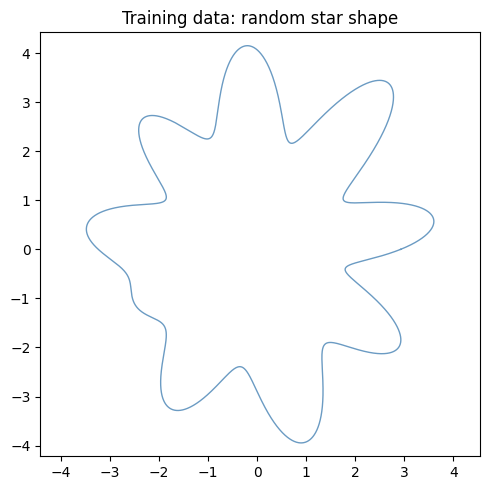

Dataset shape: torch.Size([10000, 2])


In [2]:
torch.manual_seed(0)
np.random.seed(0)

pnts, radius_fun, amplitudes, phases = create_random_star_shape(10000, num_modes=10)
pnts_tsr = 3 * torch.tensor(pnts, dtype=torch.float32)

plt.figure(figsize=(5, 5))
plt.plot(pnts_tsr[:, 0], pnts_tsr[:, 1], lw=1, alpha=0.8, color='steelblue')
plt.axis('equal')
plt.title('Training data: random star shape')
plt.tight_layout()
plt.show()
print(f'Dataset shape: {pnts_tsr.shape}')

## 2. Model setup

In [3]:
ndim            = 2
mlp_layers      = 5
mlp_hidden_dim  = 256
mlp_time_embed  = 128

model = UNetBlockStyleMLP_backbone(
    ndim=ndim,
    nlayers=mlp_layers,
    nhidden=mlp_hidden_dim,
    time_embed_dim=mlp_time_embed,
)
model_precd = EDMPrecondWrapper(model, sigma_data=0.5, sigma_min=0.002, sigma_max=80, rho=7.0)
edm_loss_fn = EDMLoss(P_mean=-1.2, P_std=1.2, sigma_data=0.5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 730,374


## 3. Training

In [4]:
lr         = 1e-3
nsteps     = 3000
batch_size = 1024

model_precd, loss_traj = train_score_model_custom_loss(
    pnts_tsr, model_precd, edm_loss_fn,
    lr=lr, nepochs=nsteps, batch_size=batch_size, device=device,
)
print(f'Initial loss: {loss_traj[0]:.4f}  |  Final loss: {loss_traj[-1]:.4f}')

  0%|          | 0/3000 [00:00<?, ?it/s]

step 0 loss 9.573
Initial loss: 9.5727  |  Final loss: 2.1867


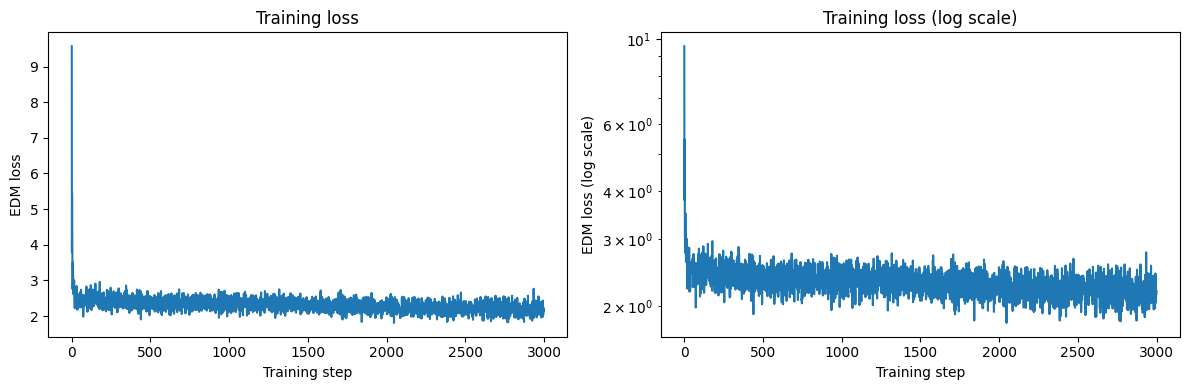

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_traj)
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('EDM loss')
axes[0].set_title('Training loss')

axes[1].semilogy(loss_traj)
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('EDM loss (log scale)')
axes[1].set_title('Training loss (log scale)')

plt.tight_layout()
plt.show()

## 4. Sampling with EDM sampler

In [6]:
n_samples  = 2000
num_steps  = 50

model_precd.eval()
latents = torch.randn(n_samples, ndim, device=device)

x_final, x_traj, x0hat_traj, t_steps = edm_sampler(
    model_precd, latents,
    num_steps=num_steps,
    sigma_min=0.002, sigma_max=80, rho=7,
    return_traj=True,
)
# x_traj shape: [num_steps+1, n_samples, ndim]
x_final_np = x_final.cpu().numpy()
x_traj_np  = x_traj.cpu().numpy()      # [T, N, 2]
print(f'Generated {n_samples} samples.  Trajectory shape: {x_traj_np.shape}')

Generated 2000 samples.  Trajectory shape: (51, 2000, 2)


## 5. Visualization

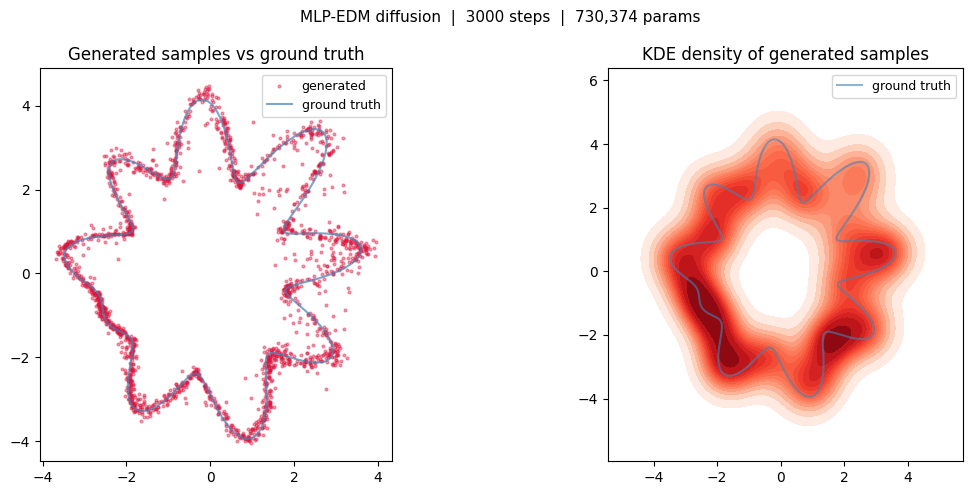

In [7]:
# --- scatter: generated vs ground truth ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_final_np[:, 0], x_final_np[:, 1],
                s=4, alpha=0.4, color='crimson', label='generated')
axes[0].plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(),
             lw=1.5, alpha=0.7, color='steelblue', label='ground truth')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=9)
axes[0].set_title('Generated samples vs ground truth')

# --- KDE density of generated samples ---
sns.kdeplot(x=x_final_np[:, 0], y=x_final_np[:, 1],
            ax=axes[1], fill=True, cmap='Reds', levels=15)
axes[1].plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(),
             lw=1.5, alpha=0.6, color='steelblue', label='ground truth')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=9)
axes[1].set_title('KDE density of generated samples')

plt.suptitle(f'MLP-EDM diffusion  |  {nsteps} steps  |  {n_params:,} params', fontsize=11)
plt.tight_layout()
plt.show()

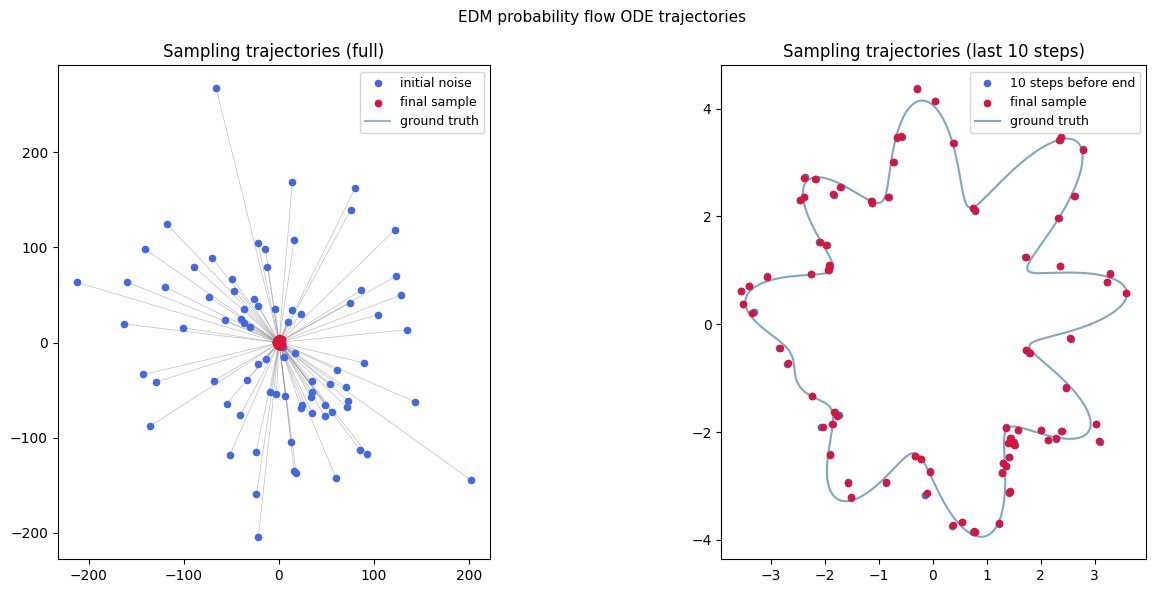

In [8]:
# --- sampling trajectories (subset of particles) ---
n_show = 80   # trajectories to draw
idx    = np.random.choice(n_samples, n_show, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: full trajectory
ax = axes[0]
ax.scatter(x_traj_np[0, idx, 0], x_traj_np[0, idx, 1],
           s=20, color='royalblue', zorder=3, label='initial noise')
ax.scatter(x_traj_np[-1, idx, 0], x_traj_np[-1, idx, 1],
           s=20, color='crimson', zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[:, i, 0], x_traj_np[:, i, 1],
            lw=0.5, alpha=0.5, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(),
        lw=1.5, alpha=0.6, color='steelblue', label='ground truth')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Sampling trajectories (full)')

# right: last 10 steps zoomed in
ax = axes[1]
ax.scatter(x_traj_np[-10, idx, 0], x_traj_np[-10, idx, 1],
           s=20, color='royalblue', zorder=3, label='10 steps before end')
ax.scatter(x_traj_np[-1, idx, 0], x_traj_np[-1, idx, 1],
           s=20, color='crimson', zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[-10:, i, 0], x_traj_np[-10:, i, 1],
            lw=0.7, alpha=0.6, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(),
        lw=1.5, alpha=0.7, color='steelblue', label='ground truth')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Sampling trajectories (last 10 steps)')

plt.suptitle('EDM probability flow ODE trajectories', fontsize=11)
plt.tight_layout()
plt.show()

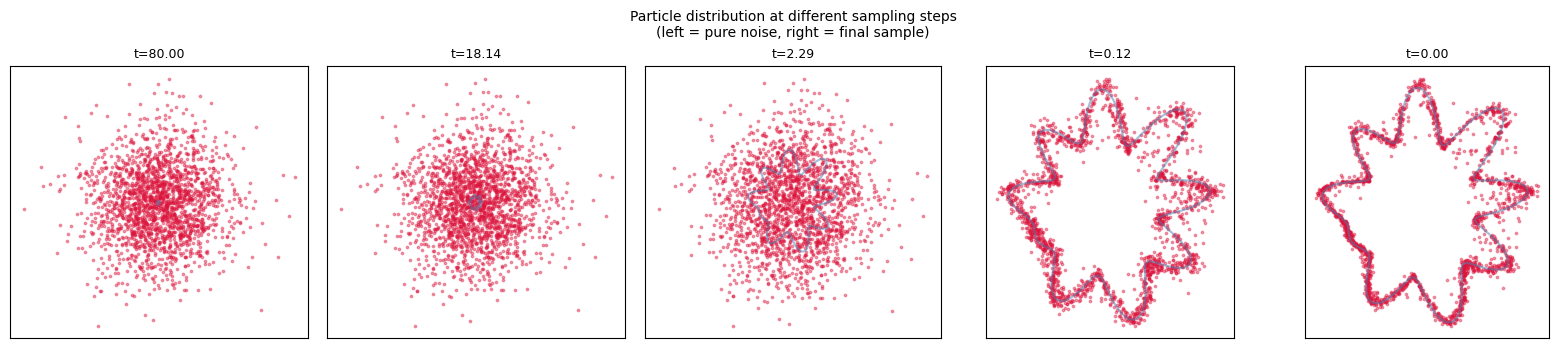

In [9]:
# --- snapshots at different diffusion timesteps ---
T = x_traj_np.shape[0]  # num_steps + 1
snap_indices = [0, T // 4, T // 2, 3 * T // 4, T - 1]
snap_labels  = [f't={t_steps[min(i, len(t_steps)-1)].item():.2f}' for i in snap_indices]

fig, axes = plt.subplots(1, len(snap_indices), figsize=(16, 3.5))
for ax, si, label in zip(axes, snap_indices, snap_labels):
    pts = x_traj_np[si]   # [N, 2]
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4, color='crimson')
    ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(),
            lw=1.5, alpha=0.5, color='steelblue')
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Particle distribution at different sampling steps\n(left = pure noise, right = final sample)', fontsize=10)
plt.tight_layout()
plt.show()